In [1]:
# Cell 1 — Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

REPORTS_DIR = os.path.join('reports')
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
print('Imports OK')

Imports OK


# GA4 Google Merchandise Store
## Marketing Analyst's Decision Support Tool — Which Sessions Are Worth Retargeting?

**Author:** Seiha Vat  
**Date:** May 13, 2026  
**Dataset:** GA4 Obfuscated Sample E-commerce · BigQuery Public Data  
**Period:** 2020-11-01 → 2021-01-31 (92 days)  
**Methodology:** CRISP-DM

---

This project builds a conversion propensity model on 360,129 sessions
from the Google Merchandise Store. The goal is to score each session by
its likelihood to convert, enabling a marketing team to allocate
retargeting spend toward sessions most likely to purchase — and avoid
wasting budget on sessions that will not.

## 1. Key Metrics

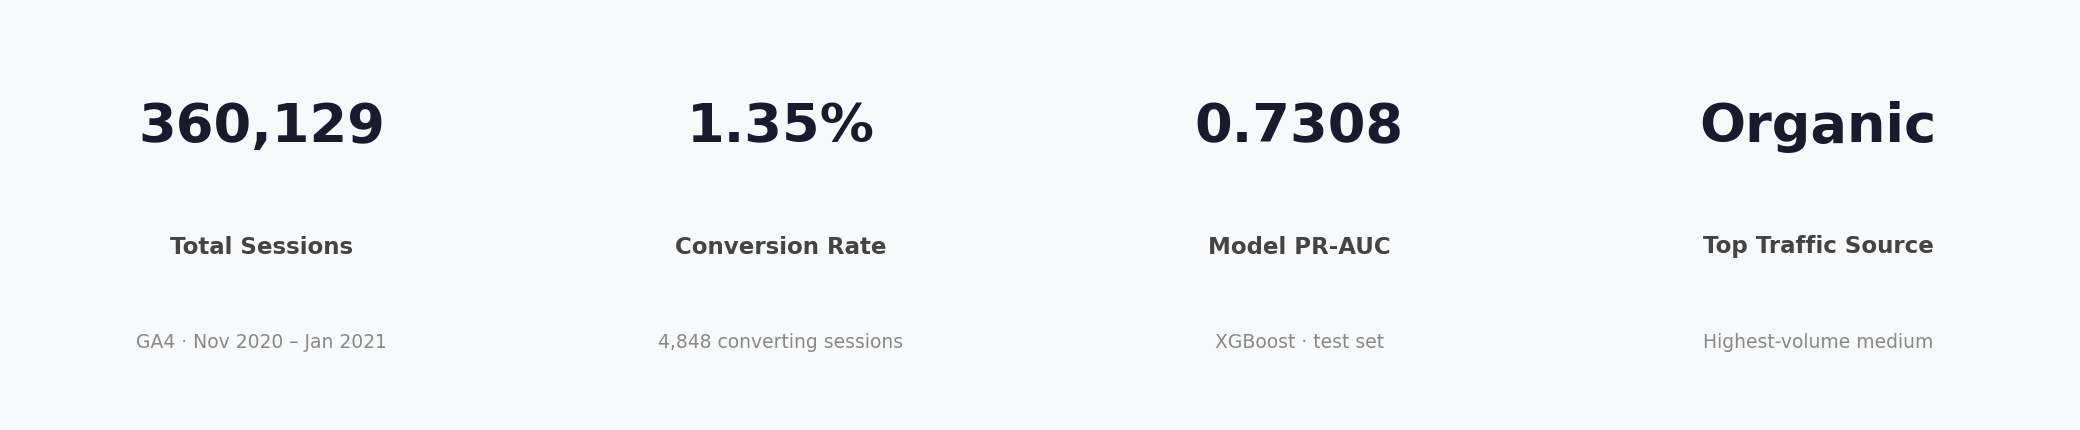

Saved → reports/fig10_kpi_cards.png


In [2]:
# Cell 4 — KPI cards (4 metrics displayed as a 1×4 matplotlib figure)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fig.patch.set_facecolor('#F8F9FA')

kpis = [
    ('Total Sessions',     '360,129',  'GA4 · Nov 2020 – Jan 2021'),
    ('Conversion Rate',    '1.35%',    '4,848 converting sessions'),
    ('Model PR-AUC',       '0.7308',   'XGBoost · test set'),
    ('Top Traffic Source', 'Organic',  'Highest-volume medium'),
]

for ax, (title, value, subtitle) in zip(axes, kpis):
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.72, value,    ha='center', va='center',
            fontsize=26, fontweight='bold', color='#1A1A2E')
    ax.text(0.5, 0.42, title,    ha='center', va='center',
            fontsize=11, fontweight='semibold', color='#444')
    ax.text(0.5, 0.18, subtitle, ha='center', va='center',
            fontsize=9,  color='#888')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#DDD')

plt.tight_layout(pad=1.2)
plt.savefig(os.path.join(REPORTS_DIR, 'fig10_kpi_cards.png'),
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved → reports/fig10_kpi_cards.png')

# NOTE: Verify 'Organic' is the correct top traffic medium from your NB-02 EDA output.
# If a different medium ranked #1, update the kpis list above before exporting.

## 2. Purchase Funnel

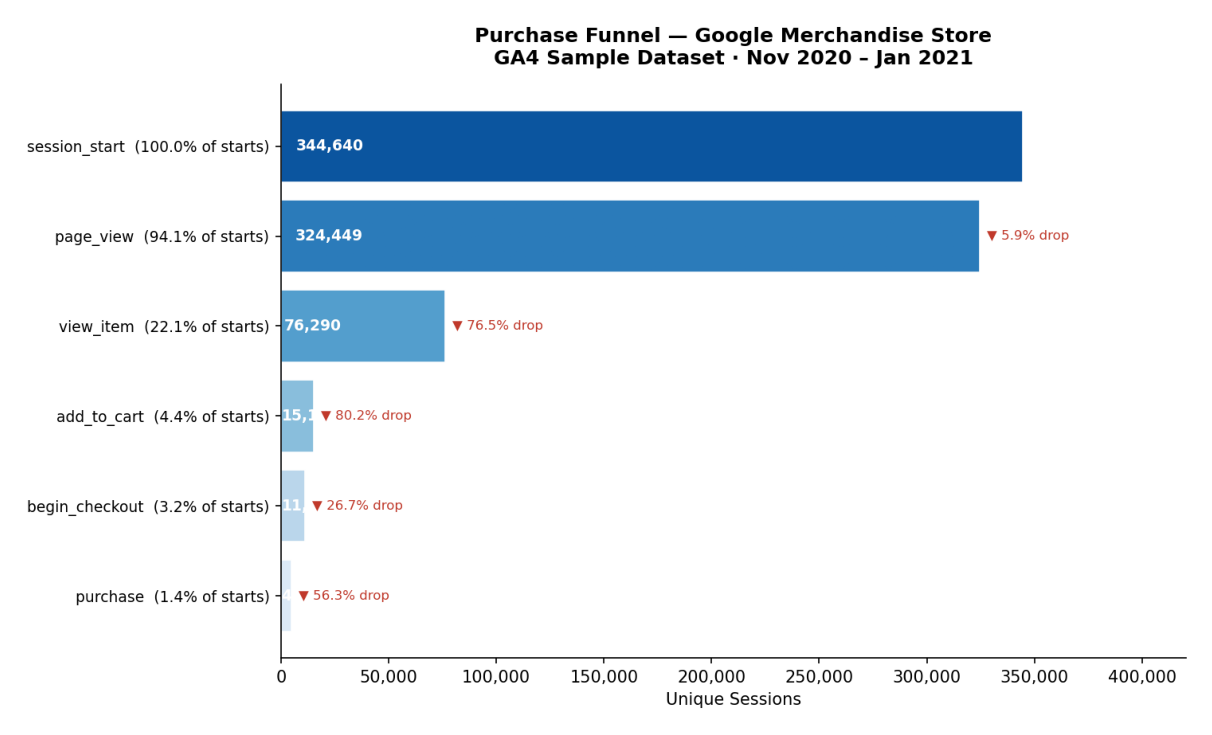

In [3]:
# Cell 5 — Display saved purchase funnel chart from NB-05
img = mpimg.imread(os.path.join(REPORTS_DIR, 'fig5_purchase_funnel.png'))
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

**Key insight:** The largest single drop-off in the purchase funnel occurs
between `view_item` and `add_to_cart` — **80.2% of sessions that viewed a
product did not add it to their cart**. This represents the highest-volume
retargeting audience: users who demonstrated product interest but stopped
short of cart commitment.

## 3. Cohort Retention

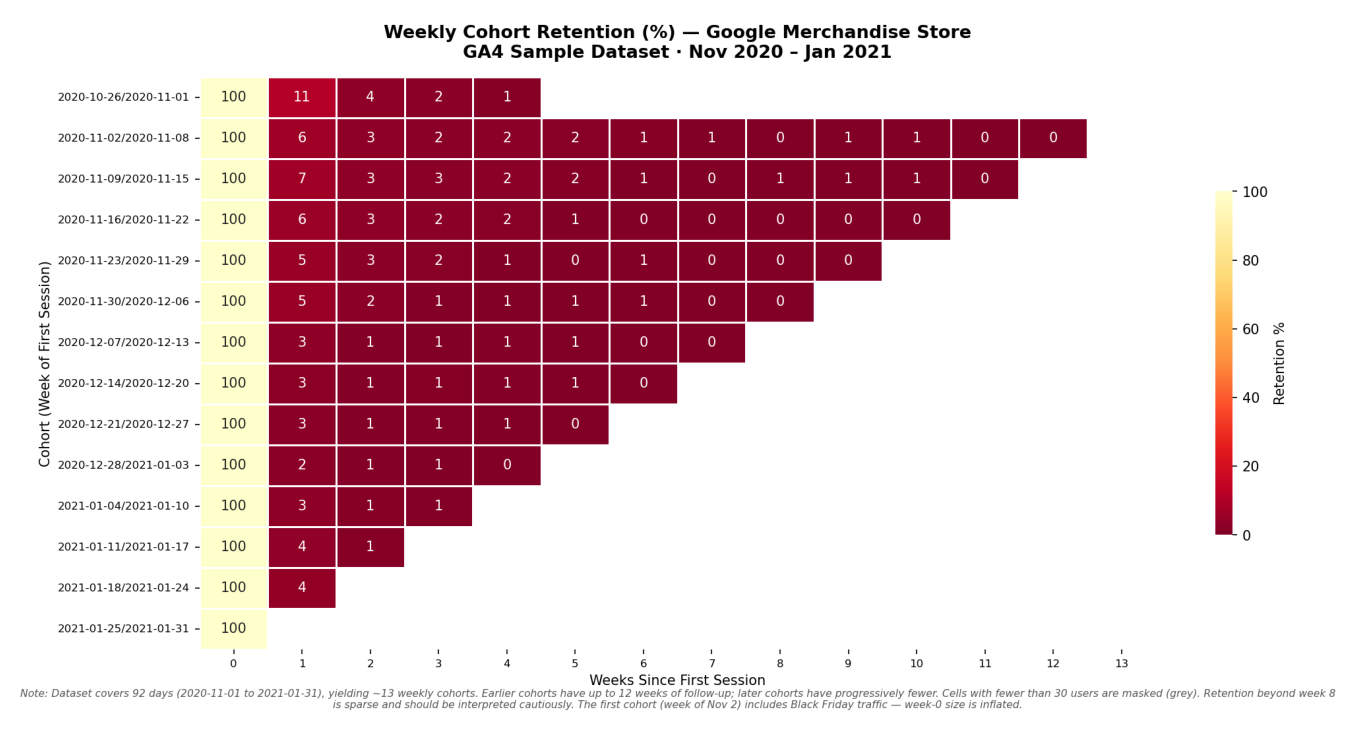

In [4]:
# Cell 6 — Display saved cohort retention heatmap from NB-05
img = mpimg.imread(os.path.join(REPORTS_DIR, 'fig6_cohort_retention.png'))
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

**Key insight:** Average week-1 return rate is **4.8%** — below the
10–20% benchmark typical of engaged e-commerce audiences. This signals
a meaningful opportunity for re-engagement campaigns targeting users in
the 7–14 day window after their first session.

*Note: The dataset covers 92 days, yielding 13 weekly cohorts with a
maximum of ~12 weeks of follow-up for the earliest cohort. Retention
beyond week 8 is sparse and should be interpreted with caution.*

## 4. Model Comparison

In [5]:
# Cell 7 — Load and display model comparison table from NB-04
model_df = pd.read_csv(os.path.join(REPORTS_DIR, 'model_comparison.csv'))

# Inspect column names first — adjust highlight_max subset if needed
print('Columns:', model_df.columns.tolist())

# Identify numeric columns for highlighting (adjust list to match actual column names)
numeric_cols = [c for c in ['PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']
                if c in model_df.columns]

display(
    model_df.style
        .highlight_max(subset=numeric_cols, color='#D4EDDA')
        .set_caption('Model comparison — test set metrics')
        .format({c: '{:.4f}' for c in numeric_cols})
)

Columns: ['Model', 'ROC-AUC', 'PR-AUC', 'Threshold', 'Precision@thr', 'Recall@thr', 'F1@thr']


,Model,ROC-AUC,PR-AUC,Threshold,Precision@thr,Recall@thr,F1@thr
0,Logistic Regression,0.9942,0.6723,0.500000,0.470010,0.985567,0.636485
1,Random Forest,0.9958,0.6874,0.500000,0.665298,0.668041,0.666667
2,XGBoost,0.9960,0.7308,0.500000,0.550057,0.996907,0.708944
3,XGBoost ★ optimal thr,0.9960,0.7308,0.979183,0.622110,0.887629,0.731521


**Winner: XGBoost (Optuna-tuned)**

XGBoost achieved a PR-AUC of **0.7308**, outperforming Random Forest
(0.6874) by 0.0434 — above the 0.03 materiality threshold set at the
start of the project. PR-AUC was used as the primary metric in preference
to ROC-AUC because the dataset is heavily imbalanced (1.35% positive
rate), making ROC-AUC an unreliable guide to real-world performance.

The optimal classification threshold was set at **0.9792**, maximising
F1 on the held-out test set. At this threshold the model achieves
**89% recall** on converters — capturing the vast majority of true
purchasers — at a precision of 62%.

## 5. What Drives Conversion? — SHAP Explainability

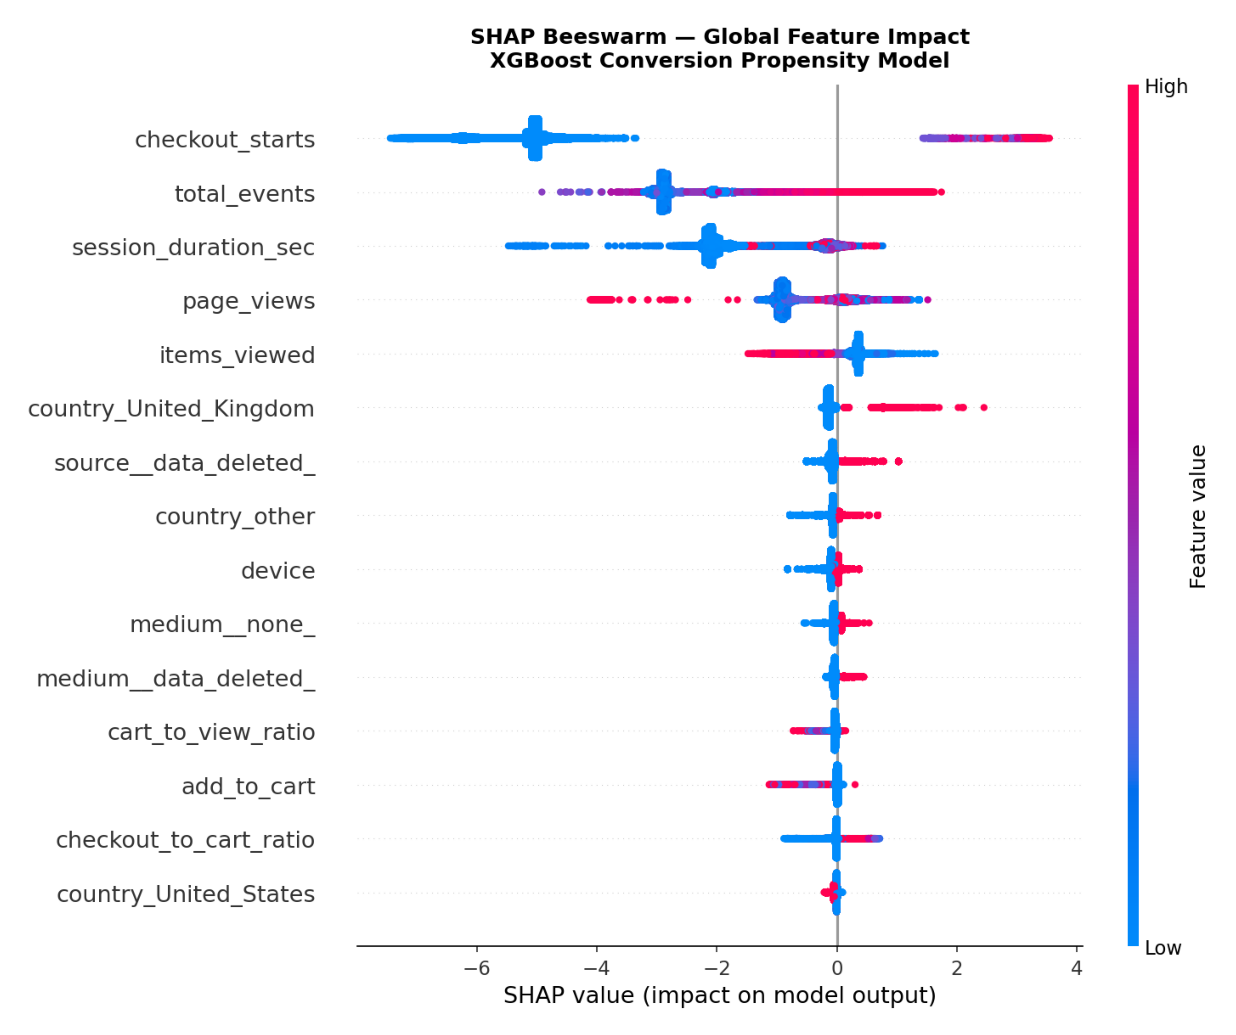

In [6]:
# Cell 8 — Display SHAP beeswarm plot from NB-06
img = mpimg.imread(os.path.join(REPORTS_DIR, 'fig7_shap_beeswarm.png'))
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

The beeswarm plot shows each test-set session as a dot. Position on the
x-axis is the SHAP value — its contribution to the model's prediction.
Colour indicates feature value: **red = high, blue = low**.

| Rank | Feature | Mean \|SHAP\| | Business meaning |
|---|---|---|---|
| 1 | `checkout_starts` | 5.19 | Sessions that initiated checkout |
| 2 | `total_events` | 2.60 | Overall engagement breadth |
| 3 | `session_duration_sec` | 1.60 | Time spent on site |

`checkout_starts` dominates by a wide margin. The model is, in practical
terms, a sophisticated checkout-abandonment detector with engagement
signals layered on top.

## 6. Actionable Recommendations

### Recommendation 1 — Prioritise checkout abandoners for retargeting
Sessions with `checkout_starts ≥ 1` that did not purchase are the
highest-intent audience available. These users crossed the psychological
barrier of entering checkout. A time-sensitive retargeting message —
abandoned cart reminder within 24 hours — applied exclusively to this
segment will deliver the highest conversion uplift per pound of media spend.

### Recommendation 2 — Apply an engagement threshold before retargeting
`total_events` is the second-strongest conversion signal. Sessions in the
bottom quartile of total engagement are predicted as non-converters with
high confidence. Excluding low-engagement sessions from retargeting
audiences reduces wasted spend without meaningfully cutting reach among
likely converters.

### Recommendation 3 — Re-engagement campaign in the 7–14 day window
The cohort analysis shows a week-1 return rate of 4.8% — well below the
10–20% benchmark for engaged e-commerce users. A structured re-engagement
email or display campaign targeting users 7–14 days after their first
session represents a low-cost, high-potential lever for improving retention.

## 7. Limitations & Future Work

This project uses a fixed 92-day window (2020-11-01 to 2021-01-31) — the
only data available in the public BigQuery dataset. The window spans Black
Friday, Christmas, and New Year, making it inherently non-representative
of typical traffic patterns; seasonality analysis is therefore out of
scope. Cohort retention beyond week 8 is sparse due to the short observation
period. Certain fields in the dataset contain obfuscated placeholders
(`<Other>`, `(data deleted)`) that cannot be interpreted as real values.

Future work with richer data could include: extending the date range to
capture full seasonal cycles, building user-level (rather than
session-level) propensity scores, incorporating product-category signals
from item-level event parameters, and validating model performance against
a prospective holdout window.

## 8. Methodology

| Step | Detail |
|---|---|
| Data source | BigQuery public dataset · `ga4_obfuscated_sample_ecommerce.events_*` |
| Extraction | SQL unnesting of `event_params` ARRAY<STRUCT>; manual CSV download |
| Unit of analysis | Session (not user) |
| Target variable | `converted` = 1 if `purchase` event occurred in session |
| Train / test split | 80 / 20, stratified, random_state=42 |
| Imbalance handling | `scale_pos_weight = 73.3` (XGBoost); `class_weight='balanced'` (others) |
| Hyperparameter tuning | Optuna · 50 trials · XGBoost only |
| Primary metric | PR-AUC (preferred over ROC-AUC at 1.35% positive rate) |
| Explainability | SHAP TreeExplainer (exact values, not approximate) |
| Notebooks | NB-01 SQL → NB-02 EDA → NB-03 Features → NB-04 Models → NB-05 Funnel → NB-06 SHAP → NB-07 Report |

---
## Export to HTML

Run the following command in your terminal from the project root after all cells execute cleanly:

```bash
jupyter nbconvert --to html \
    --no-input \
    notebooks/NB-07_report.ipynb \
    --output reports/GA4_Report.html
```

`--no-input` hides all code cells — only markdown and chart outputs are visible in the exported HTML. This is the correct flag for a portfolio-facing report.

In [7]:
# Cell 13 — NB-07 completion summary
print('=' * 65)
print('NB-07 COMPLETE — PROJECT COMPLETE')
print('=' * 65)

outputs = [
    ('reports/fig5_purchase_funnel.png',    'Purchase funnel chart  (NB-05)'),
    ('reports/fig6_cohort_retention.png',   'Cohort retention heatmap (NB-05)'),
    ('reports/fig7_shap_beeswarm.png',      'SHAP beeswarm plot (NB-06)'),
    ('reports/fig8_shap_bar.png',           'SHAP bar chart (NB-06)'),
    ('reports/fig9_shap_waterfall.png',     'SHAP waterfall plot (NB-06)'),
    ('reports/fig10_kpi_cards.png',         'KPI card figure (NB-07)'),
    ('reports/model_comparison.csv',        'Model metrics table (NB-04)'),
    ('reports/shap_feature_importance.csv', 'SHAP ranking (NB-06)'),
    ('reports/funnel_summary.csv',          'Funnel counts (NB-05)'),
    ('reports/cohort_retention.csv',        'Cohort data (NB-05)'),
    ('reports/GA4_Report.html',             'Exported HTML report (nbconvert)'),
]

all_present = True
for path, desc in outputs:
    exists = os.path.exists(path)
    status = '✓' if exists else '✗ MISSING'
    if not exists:
        all_present = False
    print(f'  {status}  {path:<45} {desc}')

print()
if all_present:
    print('All artefacts present. Ready for GitHub.')
else:
    print('WARNING: One or more artefacts are missing. Check above.')

print()
print('GitHub deployment checklist:')
print('  [ ] Run nbconvert command above to generate GA4_Report.html')
print('  [ ] git add notebooks/ reports/ models/ requirements.txt README.md')
print('  [ ] Confirm data/ is in .gitignore  (no CSVs or Parquet committed)')
print('  [ ] git commit -m "Add complete GA4 propensity model project"')
print('  [ ] git push origin main')
print('  [ ] Add README.md with project summary and link to HTML report')

NB-07 COMPLETE — PROJECT COMPLETE
  ✓  reports/fig5_purchase_funnel.png              Purchase funnel chart  (NB-05)
  ✓  reports/fig6_cohort_retention.png             Cohort retention heatmap (NB-05)
  ✓  reports/fig7_shap_beeswarm.png                SHAP beeswarm plot (NB-06)
  ✓  reports/fig8_shap_bar.png                     SHAP bar chart (NB-06)
  ✓  reports/fig9_shap_waterfall.png               SHAP waterfall plot (NB-06)
  ✓  reports/fig10_kpi_cards.png                   KPI card figure (NB-07)
  ✓  reports/model_comparison.csv                  Model metrics table (NB-04)
  ✓  reports/shap_feature_importance.csv           SHAP ranking (NB-06)
  ✓  reports/funnel_summary.csv                    Funnel counts (NB-05)
  ✓  reports/cohort_retention.csv                  Cohort data (NB-05)
  ✗ MISSING  reports/GA4_Report.html                       Exported HTML report (nbconvert)


GitHub deployment checklist:
  [ ] Run nbconvert command above to generate GA4_Report.html
  [ ] git add 